# Deep Learning Lab (CS 405)
## EXPERIMENT 5: Image Denoising and Feature Learning using Autoencoders

---

**Student Name:** Nabeel Shan  
**Registration No:** 468752  
**Course:** BESE-29

---

### Objective:
To understand and implement Convolutional Autoencoders (AEs) for feature extraction, data denoising, and dimensionality reduction on the Fashion MNIST dataset using Keras and TensorFlow. This implementation includes architectural design, latent space feature map visualization, and quantitative mathematical evaluation of signal restoration (PSNR).

## 1. Environment Setup & Dependency Management
Before building the architecture, we configure the environment.
* **Dependency Pinning:** We strictly pin the NumPy version (`<2.0.0`) to ensure compatibility with the `imgaug` library, preventing API deprecation crashes.
* **Library Imports:** Loading TensorFlow/Keras for model architecture, OpenCV/ImgAug for image processing, and Matplotlib for visualization.

In [ ]:
# !pip install "numpy<2.0.0" imgaug

In [ ]:
import sys
import warnings
import os
import glob
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, UpSampling2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing import image

from imgaug import augmenters
import matplotlib.pyplot as plt

# Set default colormap for matplotlib to grayscale
plt.rcParams['image.cmap'] = 'gray'

## 2. Data Ingestion & Normalization
We load the Fashion MNIST dataset and prepare it for neural network ingestion.
* **Normalization:** Neural networks converge faster and avoid vanishing/exploding gradients when inputs are scaled. We divide the pixel intensity matrix by 255 to restrict all values to the domain $[0, 1]$.
* **Reshaping:** Convolutional layers require a dedicated channel dimension. We reshape the arrays to $(N, 28, 28, 1)$ representing $N$ grayscale images.

In [ ]:
# ---------------------------------------------------------
# Direct Keras Loading
# ---------------------------------------------------------
(train_x, _), (test_x, _) = tf.keras.datasets.fashion_mnist.load_data()
train_x = np.vstack((train_x, test_x)) # Combine to match the manual's manual splitting

# Create train and validation datasets
train_x, val_x = train_test_split(train_x, test_size=0.15, random_state=42)

# Normalize and reshape to (28, 28, 1)
train_x = train_x.astype('float32') / 255.
val_x = val_x.astype('float32') / 255.
train_x = train_x.reshape(-1, 28, 28, 1)
val_x = val_x.reshape(-1, 28, 28, 1)

print(f"Training data shape: {train_x.shape}")

Training data shape: (59500, 28, 28, 1)


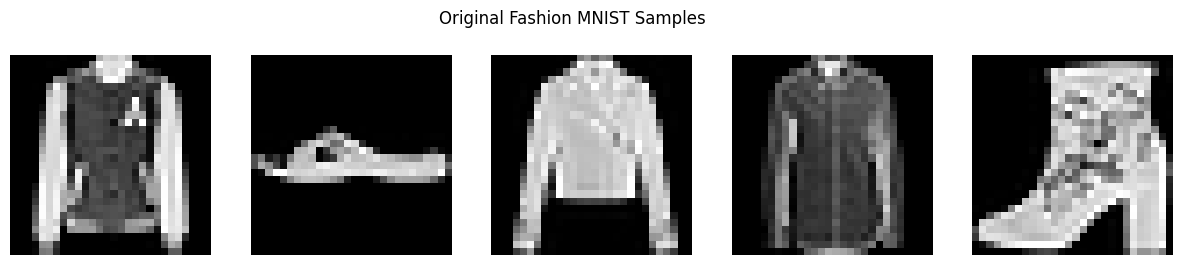

In [ ]:
# Visualizing Samples
f, ax = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax[i].imshow(train_x[i, :, :, 0])
    ax[i].axis('off')
plt.suptitle("Original Fashion MNIST Samples")
plt.show()

## 3. Data Perturbation (Simulating Corrupted Data)
To train a Denoising Autoencoder, we must deliberately corrupt the input data. We inject **Salt and Pepper noise** (randomly setting pixels to pure white or pure black).
* **Objective:** The network will be trained to map the noisy input back to the clean target. This forces the model to learn the underlying structural features of the clothing, effectively ignoring the random, incompressible noise.

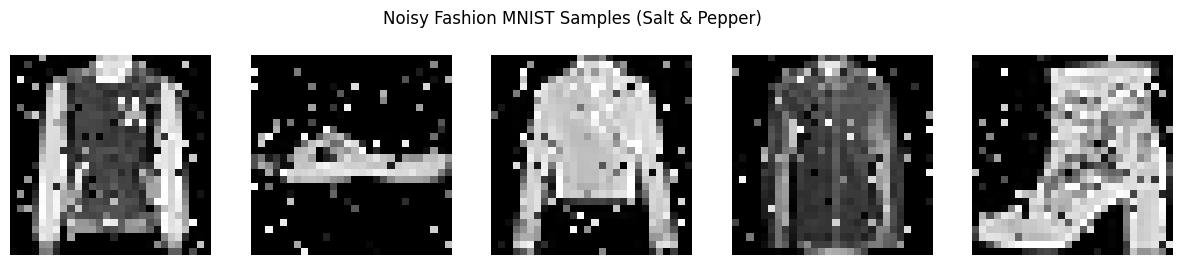

In [ ]:
# DENOISING PREP - ADDING NOISE
# Add Salt and Pepper noise to simulate corrupted data
noise = augmenters.SaltAndPepper(0.1)
seq_object = augmenters.Sequential([noise])

# Augmenters expect images in range 0-255, so we scale up, augment, and scale down
train_x_n = seq_object.augment_images((train_x * 255).astype(np.uint8)) / 255.0
val_x_n = seq_object.augment_images((val_x * 255).astype(np.uint8)) / 255.0

# Visualize Noisy Samples
f, ax = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax[i].imshow(train_x_n[i, :, :, 0])
    ax[i].axis('off')
plt.suptitle("Noisy Fashion MNIST Samples (Salt & Pepper)")
plt.show()

## 4. Autoencoder Architecture Design
The architecture acts as an informational bottleneck, forcing the data through a lower-dimensional space.
* **The Encoder:** Uses `Conv2D` to extract feature maps and `MaxPool2D` to downsample spatial dimensions. The $28 \times 28 \times 1$ image is aggressively compressed down to a $4 \times 4 \times 16$ latent tensor.
* **The Decoder:** Reconstructs the image from the latent space using `UpSampling2D` to expand spatial dimensions and `Conv2D` to synthesize the pixels.
* **Output Activation:** A `sigmoid` activation is applied to the final layer to ensure all output pixel predictions remain bounded in the $[0, 1]$ range.

In [ ]:
# Input layer
input_layer = Input(shape=(28, 28, 1))

# --- ENCODER ---
encoded_layer1 = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
encoded_layer1 = MaxPool2D((2, 2), padding='same')(encoded_layer1) # Shrinks to 14x14
encoded_layer2 = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_layer1)
encoded_layer2 = MaxPool2D((2, 2), padding='same')(encoded_layer2) # Shrinks to 7x7
encoded_layer3 = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded_layer2)
latent_view    = MaxPool2D((2, 2), padding='same')(encoded_layer3) # Shrinks to 4x4 (Latent Space)

# --- DECODER ---
decoded_layer1 = Conv2D(16, (3, 3), activation='relu', padding='same')(latent_view)
decoded_layer1 = UpSampling2D((2, 2))(decoded_layer1) # Grows to 8x8
decoded_layer2 = Conv2D(32, (3, 3), activation='relu', padding='same')(decoded_layer1)
decoded_layer2 = UpSampling2D((2, 2))(decoded_layer2) # Grows to 16x16
decoded_layer3 = Conv2D(64, (3, 3), activation='relu')(decoded_layer2) # No padding shrinks to 14x14
decoded_layer3 = UpSampling2D((2, 2))(decoded_layer3) # Grows to 28x28
output_layer   = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(decoded_layer3) # Output: 28x28x1

# Compile the model
model = Model(input_layer, output_layer)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,761 (194.38 KB)

 Trainable params: 49,761 (194.38 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training & Optimization
We compile the network using the Adam optimizer and minimize the **Mean Squared Error (MSE)** loss function:
$$\mathcal{L}(x, \hat{x}) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2$$
* **Early Stopping:** A callback is utilized to monitor validation loss. If the network begins to overfit (memorizing the noise rather than learning the generalized structure), training halts automatically.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=1, mode='auto')

# Train: Input is Noisy (train_x_n), Target is Clean (train_x)
history = model.fit(
    train_x_n, train_x,
    epochs=20,
    batch_size=2048,
    validation_data=(val_x_n, val_x),
    callbacks=[early_stopping]
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 304ms/step - loss: 0.1394 - val_loss: 0.0618
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0516 - val_loss: 0.0360
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0341 - val_loss: 0.0296
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0287 - val_loss: 0.0263
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0257 - val_loss: 0.0239
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0238 - val_loss: 0.0232
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0229 - val_loss: 0.0214
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0214 - val_loss: 0.0207
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0209 - val_loss: 0.0199
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0202 - val_loss: 0.0194
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0197 - val_loss: 0.0192
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/ste

## 6. Convergence Analysis (Learning Curves)
Visualizing the error drop across epochs proves the model is learning dynamically. We expect both training and validation loss to decay exponentially and stabilize. A diverging validation curve would indicate overfitting.

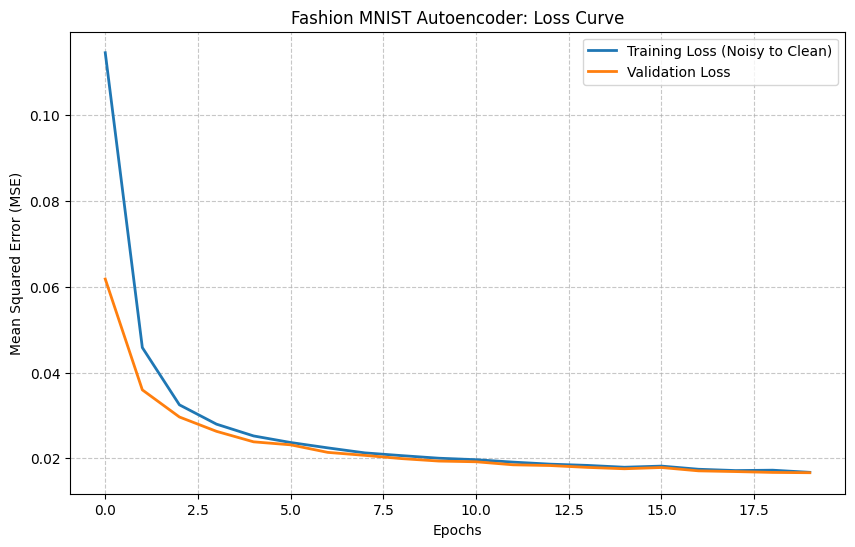

In [ ]:
# This plots the error drop over epochs for the first model
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (Noisy to Clean)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Fashion MNIST Autoencoder: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Latent Space Extraction (The Bottleneck)
To understand what the network considers "important," we isolate the encoder and predict on the validation set. This outputs the compressed **Latent Representation**.

In [ ]:
# 1. Visualize Intermediate Layers (Latent Representation)
model_2 = Model(input_layer, latent_view)
model_2.compile(optimizer='adam', loss='mse')

n = np.random.randint(0, len(val_x)-5)
preds_latent = model_2.predict(val_x_n[n:n+5])

print(f"Latent representation shape: {preds_latent.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Latent representation shape: (5, 4, 4, 16)


## 8. Visualizing the Compressed Feature Maps
The latent space is a $4 \times 4 \times 16$ tensor. By plotting these 16 channels individually, we can open the "black box" of the CNN. These abstract blocks represent the fundamental geometric primitives (edges, textures, contours) the network has compressed the original clothing items into.

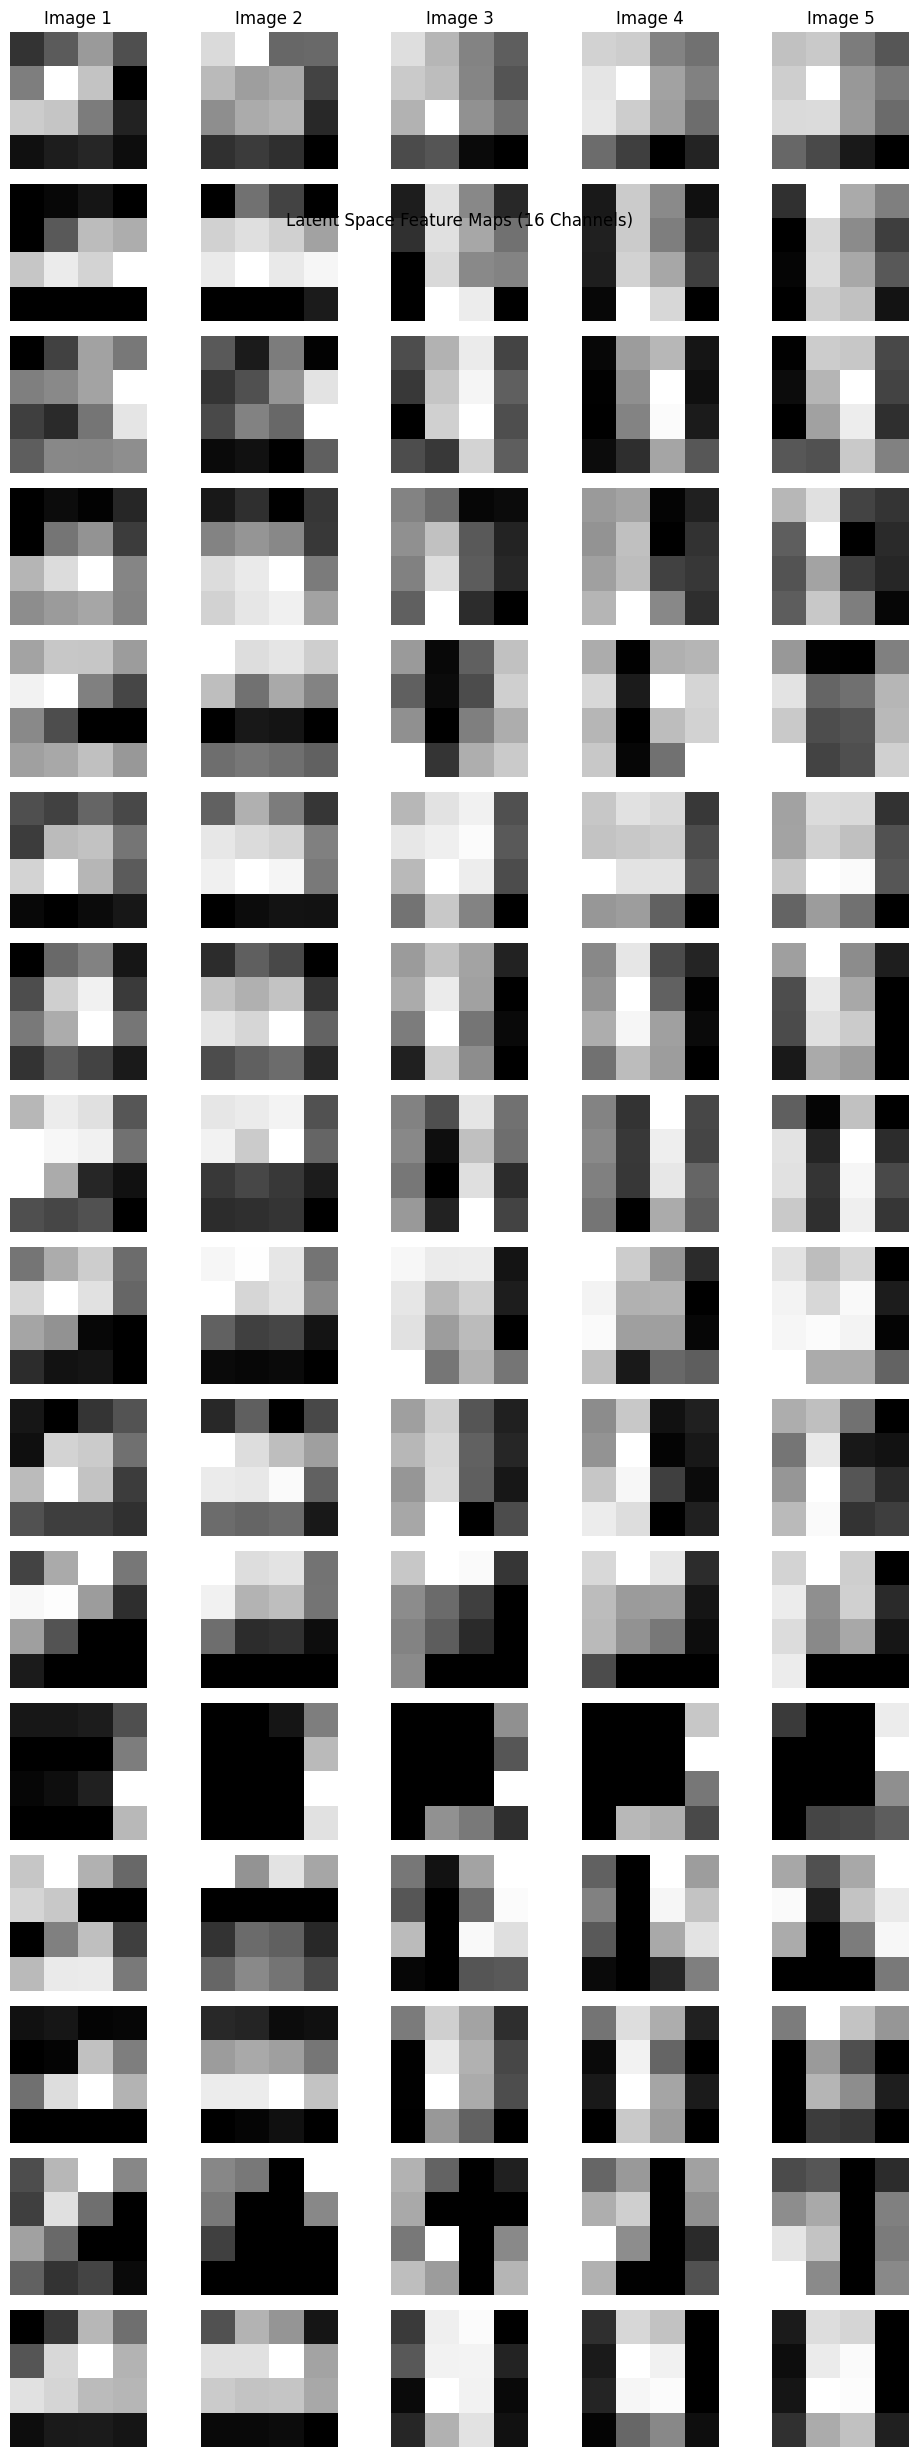

In [ ]:
# Plotting the 16 compressed channels for the 5 sample images
f, ax = plt.subplots(16, 5, figsize=(10, 25))
for j in range(16): # Iterate through the 16 channels
    for i in range(5): # Iterate through the 5 sample images
        ax[j, i].imshow(preds_latent[i, :, :, j])
        ax[j, i].axis('off')
        if j == 0:
            ax[j, i].set_title(f"Image {i+1}")
        if i == 0:
            ax[j, i].set_ylabel(f"Channel {j+1}")

plt.suptitle("Latent Space Feature Maps (16 Channels)", y=0.9)
plt.tight_layout()
plt.show()

## 9. Final Reconstruction & Visual Evaluation
We evaluate the full generative pipeline by passing unseen noisy images through the network.
* **Top Row:** The true, ground-truth clean images.
* **Middle Row:** The noisy inputs fed into the model.
* **Bottom Row:** The model's predicted reconstruction, demonstrating its ability to filter out non-essential noise and restore the original signal.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step


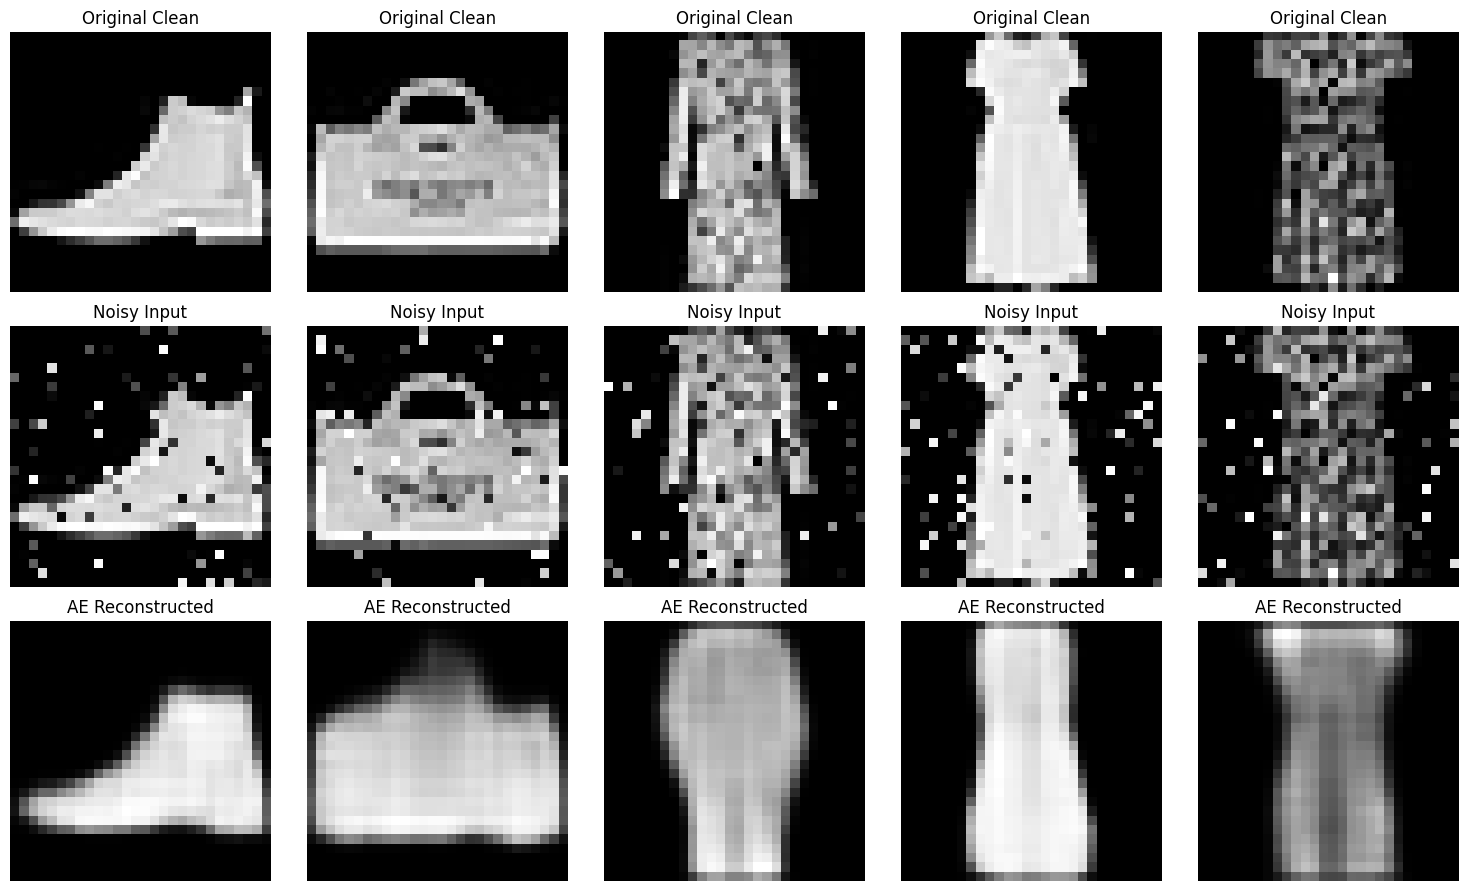

In [ ]:
# 2. Visualize Reconstructed Samples
preds_reconstructed = model.predict(val_x_n[n:n+5])

f, ax = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Original Clean
    ax[0, i].imshow(val_x[n+i, :, :, 0])
    ax[0, i].set_title("Original Clean")
    ax[0, i].axis('off')

    # Noisy Input
    ax[1, i].imshow(val_x_n[n+i, :, :, 0])
    ax[1, i].set_title("Noisy Input")
    ax[1, i].axis('off')

    # Reconstructed Output
    ax[2, i].imshow(preds_reconstructed[i, :, :, 0])
    ax[2, i].set_title("AE Reconstructed")
    ax[2, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# CELL: QUANTITATIVE EVALUATION (PSNR)
print("--- Quantitative Signal Restoration (PSNR) ---")

# Convert tensors to float32 for metric calculation
true_clean_images = tf.cast(val_x[n:n+5], tf.float32)
noisy_input_images = tf.cast(val_x_n[n:n+5], tf.float32)
denoised_images = tf.cast(preds_reconstructed, tf.float32)

# Calculate PSNR (higher is better)
psnr_before = tf.image.psnr(true_clean_images, noisy_input_images, max_val=1.0)
psnr_after = tf.image.psnr(true_clean_images, denoised_images, max_val=1.0)

print(f"Average PSNR BEFORE Denoising: {np.mean(psnr_before.numpy()):.2f} dB")
print(f"Average PSNR AFTER Denoising:  {np.mean(psnr_after.numpy()):.2f} dB")
print(f"Total Decibel Improvement:     {np.mean(psnr_after.numpy()) - np.mean(psnr_before.numpy()):.2f} dB")

--- Quantitative Signal Restoration (PSNR) ---
Average PSNR BEFORE Denoising: 15.31 dB
Average PSNR AFTER Denoising:  17.57 dB
Total Decibel Improvement:     2.26 dB


## 10. Challenge 01: Stress Testing the Noise Threshold
A robust model must have a mathematically definable breaking point. If we increase the Salt and Pepper noise from `0.1` (10%) to `0.50` (50%), half of the image information is completely destroyed. We will pass this severely corrupted data through our *already trained* Autoencoder to see if the $4 \times 4 \times 16$ latent space can still extract the geometric primitives of a shoe or shirt.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


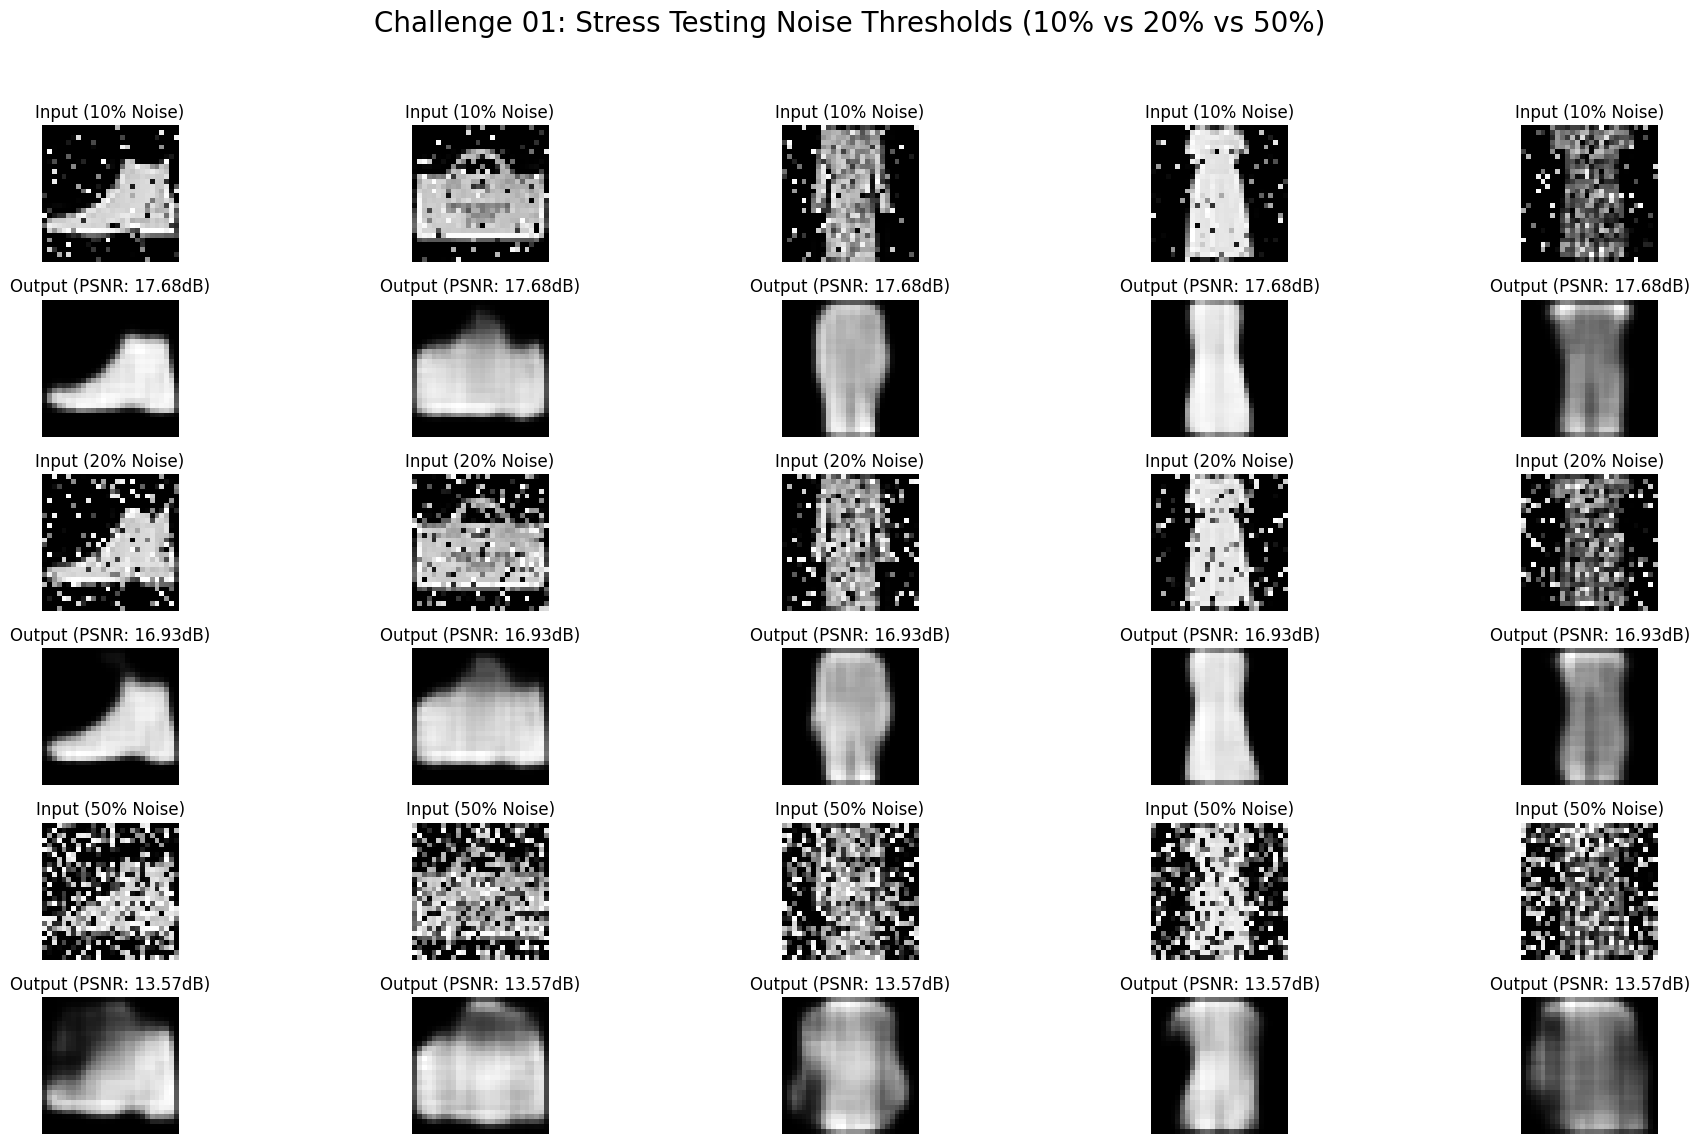

In [ ]:
# CELL 10: COMPARATIVE STRESS TEST (Finding the Threshold)
noise_levels = [0.10, 0.20, 0.50] # 10%, 20%, and 50% noise
plt.figure(figsize=(20, 12))

for row, level in enumerate(noise_levels):
    # 1. Generate noise at this specific level
    noise_obj = augmenters.SaltAndPepper(level)
    noisy_images = noise_obj.augment_images((val_x[n:n+5] * 255).astype(np.uint8)) / 255.0

    # 2. Predict using our trained model
    predictions = model.predict(noisy_images)

    # 3. Calculate Average PSNR for this level
    avg_psnr = np.mean(tf.image.psnr(tf.cast(val_x[n:n+5], tf.float32),
                                    tf.cast(predictions, tf.float32), max_val=1.0))

    # 4. Plotting
    for i in range(5):
        # Plot Noisy Input
        plt.subplot(len(noise_levels) * 2, 5, row * 10 + i + 1)
        plt.imshow(noisy_images[i, :, :, 0])
        plt.title(f"Input ({int(level*100)}% Noise)")
        plt.axis('off')

        # Plot Reconstruction
        plt.subplot(len(noise_levels) * 2, 5, row * 10 + i + 6)
        plt.imshow(predictions[i, :, :, 0])
        plt.title(f"Output (PSNR: {avg_psnr:.2f}dB)")
        plt.axis('off')

plt.suptitle("Challenge 01: Stress Testing Noise Thresholds (10% vs 20% vs 50%)", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 11. Challenge 02: Tweaking the Information Bottleneck
In the original architecture, our latent space had 16 filters. Here, we build a **Severe Bottleneck Autoencoder**. We drop the final encoder `Conv2D` layer to just **2 filters**. This forces the network to compress the $28 \times 28$ image into a tiny $4 \times 4 \times 2$ tensor (only 32 numbers total).
* **Hypothesis:** This extreme compression will cause massive information loss, resulting in highly blurred, generic reconstructions because the network lacks the "memory" capacity to store fine details.

Training Severe Bottleneck Model (2 filters) for 10 epochs...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step


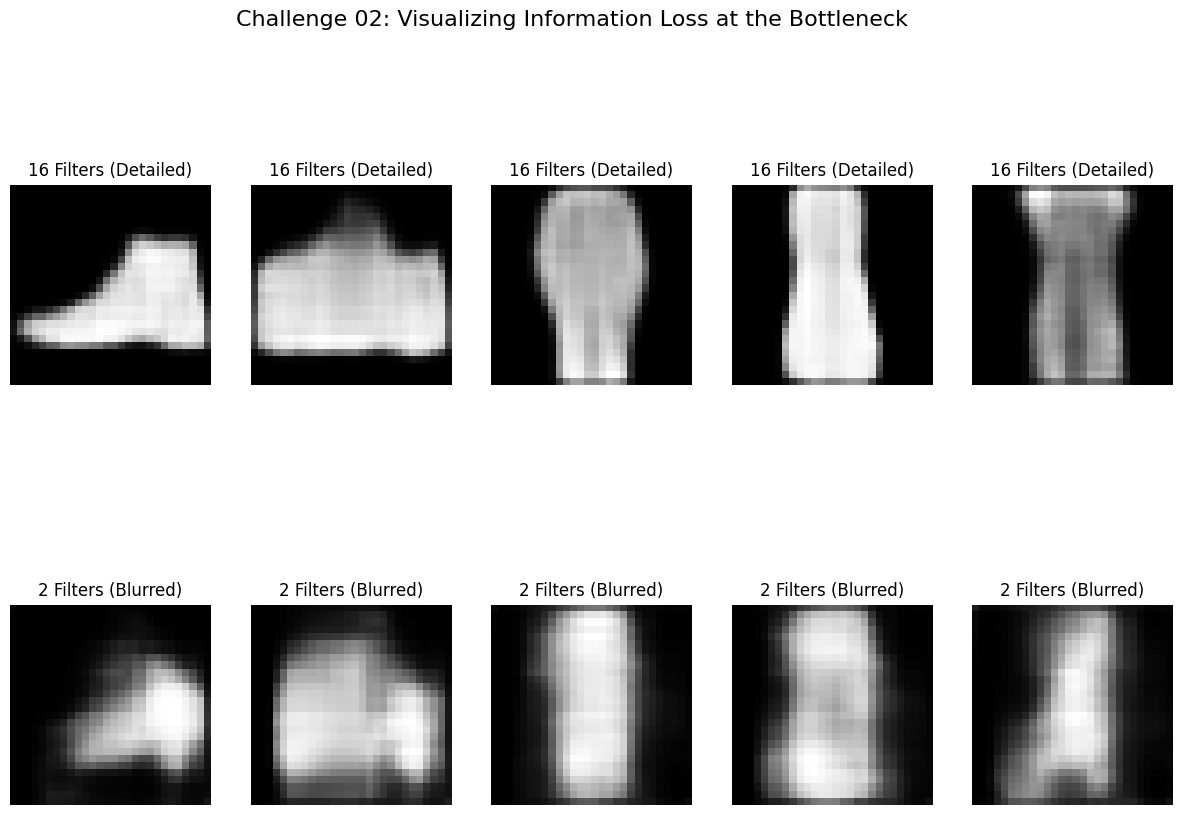

Standard Model (16 filters) PSNR: 17.57 dB
Severe Bottleneck (2 filters) PSNR: 13.59 dB


In [ ]:
# CELL 11: CHALLENGE 02 - INFORMATION LOSS COMPARISON
# 1. Define the Severe Bottleneck Architecture (Only 2 filters in latent space)
narrow_input = Input(shape=(28, 28, 1))
e = Conv2D(32, (3, 3), activation='relu', padding='same')(narrow_input)
e = MaxPool2D((2, 2), padding='same')(e)
e = Conv2D(16, (3, 3), activation='relu', padding='same')(e)
e = MaxPool2D((2, 2), padding='same')(e)
narrow_latent = Conv2D(2, (3, 3), activation='relu', padding='same')(e)
narrow_latent_view = MaxPool2D((2, 2), padding='same')(narrow_latent) # Space: 4x4x2 (32 values)

d = Conv2D(2, (3, 3), activation='relu', padding='same')(narrow_latent_view)
d = UpSampling2D((2, 2))(d)
d = Conv2D(16, (3, 3), activation='relu', padding='same')(d)
d = UpSampling2D((2, 2))(d)
d = Conv2D(32, (3, 3), activation='relu')(d)
d = UpSampling2D((2, 2))(d)
narrow_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(d)

narrow_model = Model(narrow_input, narrow_output)
narrow_model.compile(optimizer='adam', loss='mse')

print("Training Severe Bottleneck Model (2 filters) for 10 epochs...")
narrow_model.fit(train_x_n, train_x, epochs=10, batch_size=2048, validation_data=(val_x_n, val_x), verbose=0)

# 2. Comparison Visualization
preds_original = model.predict(val_x_n[n:n+5]) # Your 16-filter model
preds_narrow = narrow_model.predict(val_x_n[n:n+5]) # Your new 2-filter model

plt.figure(figsize=(15, 10))
for i in range(5):
    # Standard Model (16 filters)
    plt.subplot(2, 5, i + 1)
    plt.imshow(preds_original[i].reshape(28, 28))
    plt.title("16 Filters (Detailed)")
    plt.axis('off')

    # Severe Bottleneck (2 filters)
    plt.subplot(2, 5, i + 6)
    plt.imshow(preds_narrow[i].reshape(28, 28))
    plt.title("2 Filters (Blurred)")
    plt.axis('off')

plt.suptitle("Challenge 02: Visualizing Information Loss at the Bottleneck", fontsize=16)
plt.show()

# 3. Final Comparison Metric
psnr_orig = np.mean(tf.image.psnr(tf.cast(val_x[n:n+5], tf.float32), tf.cast(preds_original, tf.float32), max_val=1.0))
psnr_narrow = np.mean(tf.image.psnr(tf.cast(val_x[n:n+5], tf.float32), tf.cast(preds_narrow, tf.float32), max_val=1.0))

print(f"Standard Model (16 filters) PSNR: {psnr_orig:.2f} dB")
print(f"Severe Bottleneck (2 filters) PSNR: {psnr_narrow:.2f} dB")

## 12. Challenge 03: Enter the Generative Space (Variational Autoencoder)
Standard Autoencoders map images to rigid points, making them terrible at generating *new* data. A **Variational Autoencoder (VAE)** maps inputs to a probability distribution $\mathcal{N}(\mu, \sigma^2)$. By applying the **Reparameterization Trick** ($z = \mu + e^{\frac{1}{2}\sigma} \odot \epsilon$), we can backpropagate through random sampling.


Our loss function now mathematically balances perfect reconstruction with a smooth, continuous latent space using **Kullback-Leibler (KL) Divergence**:
$$\mathcal{L}_{VAE} = ||x - \hat{x}||^2 - \frac{1}{2} \sum_{j=1}^{J} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2\right)$$

Once trained, we completely discard the Encoder. We will feed pure mathematical noise (random coordinates) directly into the Decoder to hallucinate clothing that never existed in the dataset.

Standard AE Weights Saved successfully.

Training VAE (Constructing generative manifold)...
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - kl_loss: 1.1849 - reconstruction_loss: 484.8553 - total_loss: 486.0403
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - kl_loss: 4.1055 - reconstruction_loss: 372.5362 - total_loss: 376.6417
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 5.2723 - reconstruction_loss: 351.0714 - total_loss: 356.3437
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 8.0637 - reconstruction_loss: 330.2489 - total_loss: 338.3126
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 8.9599 - reconstruction_loss: 316.7299 - total_loss: 325.6899
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - kl_loss: 9.3947 - reconstruction_loss: 302.1099 - total_loss: 311.5046
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - kl_loss: 9.4060 - reconstruction_loss: 287.0525 - total_loss: 296.4586
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 2

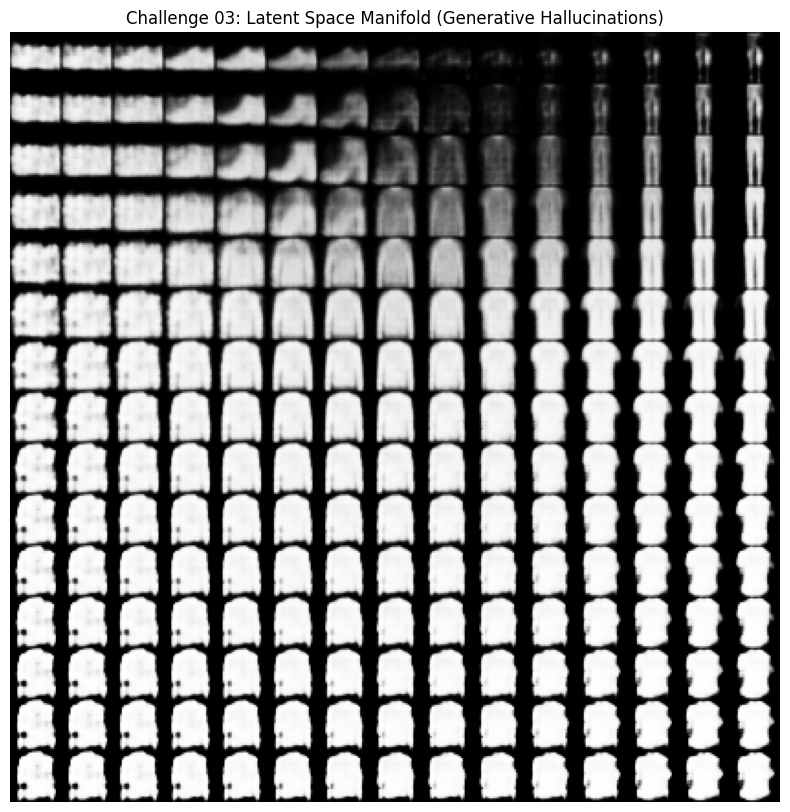

In [ ]:
# CELL 12: IMPLEMENTING THE VARIATIONAL AUTOENCODER (VAE)
import tensorflow as tf
from tensorflow.keras import layers, Model, ops
import numpy as np
import matplotlib.pyplot as plt

# 1. Save original model weights
model.save_weights('standard_ae_weights.weights.h5')
print("Standard AE Weights Saved successfully.")

latent_dim = 2

# --- VAE ENCODER ---
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Reparameterization Layer
class Sampler(layers.Layer):
    def call(self, z_mean, z_log_var):
        batch_size = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch_size, dim))
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

z = Sampler()(z_mean, z_log_var)
encoder_vae = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# --- VAE DECODER ---
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder_vae = Model(latent_inputs, decoder_outputs, name="decoder")

# --- VAE CLASS (Handles Custom Loss) ---
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

# --- TRAIN VAE ---
vae_model = VAE(encoder_vae, decoder_vae)
vae_model.compile(optimizer='adam')

print("\nTraining VAE (Constructing generative manifold)...")
# Note: In VAEs, we often use binary_crossentropy for reconstruction on normalized data
vae_model.fit(train_x, epochs=15, batch_size=1024, verbose=1)

# --- VISUALIZE MANIFOLD ---
n_grid = 15
digit_size = 28
figure = np.zeros((digit_size * n_grid, digit_size * n_grid))
grid_x = np.linspace(-3, 3, n_grid)
grid_y = np.linspace(-3, 3, n_grid)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder_vae.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.title("Challenge 03: Latent Space Manifold (Generative Hallucinations)")
plt.axis('off')
plt.show()